# 🧠 Wykład: Embeddingi – Jak AI rozumie znaczenie słów?

Witajcie na dzisiejszych zajęciach! Do tej pory dowiedzieliście się, jak modele językowe przewidują kolejne słowa i czym jest tokenizacja. Dzisiaj pójdziemy o krok dalej – dowiemy się, **w jaki sposób komputer w ogóle "widzi" znaczenie słów**.

Zamiast traktować słowa jako zwykłe ciągi liter, nauczymy się zamieniać je na **punkty w przestrzeni**.

## 1. Przypomnienie: Co to jest wektor?

Wyobraźcie sobie mapę. Każdy punkt na mapie ma swoje współrzędne: **X** (szerokość) i **Y** (długość).
* Punkt A = [2, 3]
* Punkt B = [5, 1]

W świecie AI, **wektor** to po prostu lista liczb, która opisuje położenie obiektu w jakiejś przestrzeni. Jeśli dodamy trzeci wymiar (wysokość), będziemy mieli wektor `[x, y, z]`.

W zaawansowanych modelach AI używamy wektorów, które mają setki lub tysiące wymiarów! Każdy z tych wymiarów może odpowiadać za jakąś cechę, np. "jak bardzo to słowo dotyczy jedzenia" albo "czy to słowo ma charakter negatywny".

### 1.1. Podobieństwo Cosinusowe (Cosine Similarity)

Kiedy mamy dwa punkty (wektory), chcemy wiedzieć, jak bardzo są do siebie podobne. Możemy zmierzyć odległość między nimi, ale w AI lepiej sprawdza się **kąt**.

* **Mały kąt (wynik blisko 1):** Wektory "patrzą" w tę samą stronę. Słowa są bardzo podobne (np. "pies" i "szczeniak").
* **Kąt prosty 90° (wynik 0):** Słowa nie mają ze sobą nic wspólnego (np. "lodówka" i "demokracja").
* **Kąt 180° (wynik -1):** Słowa są przeciwieństwami.

W zadaniach będziecie używać funkcji `util.cos_sim`. Pamiętajcie: wynik bliższy **1.0** to większe podobieństwo!

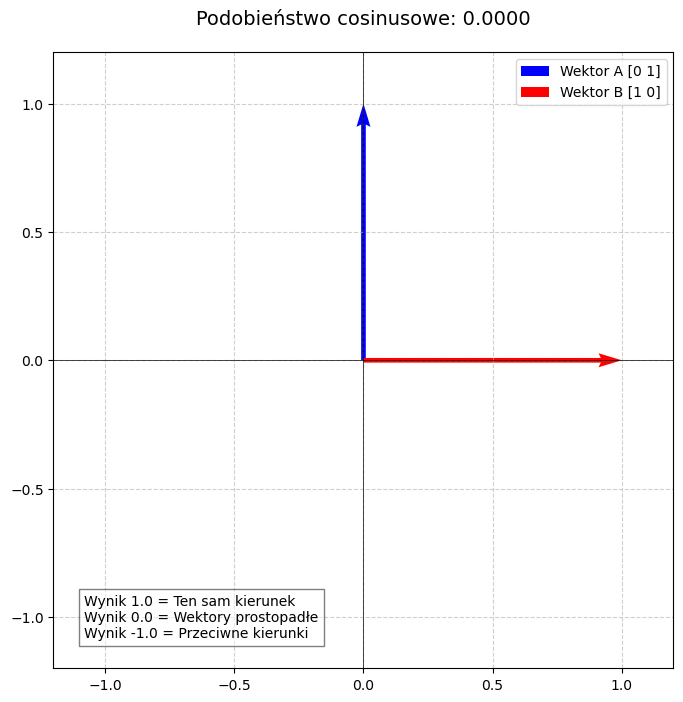

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def narysuj_wektory_i_cosinus(v1, v2):
    # Przygotowanie danych do obliczeń
    v1 = np.array(v1).reshape(1, -1)
    v2 = np.array(v2).reshape(1, -1)
    
    # Obliczanie podobieństwa cosinusowego
    podobienstwo = cosine_similarity(v1, v2)[0][0]
    
    # Konfiguracja wykresu
    plt.figure(figsize=(8, 8))
    ax = plt.gca()
    
    # Rysowanie wektorów (strzałek)
    ax.quiver(0, 0, v1[0][0], v1[0][1], angles='xy', scale_units='xy', scale=1, color='blue', label=f'Wektor A {v1[0]}')
    ax.quiver(0, 0, v2[0][0], v2[0][1], angles='xy', scale_units='xy', scale=1, color='red', label=f'Wektor B {v2[0]}')
    
    # Ustawienia osi
    limit = max(np.abs([v1, v2]).max() * 1.2, 1)
    plt.xlim(-limit, limit)
    plt.ylim(-limit, limit)
    plt.axhline(0, color='black',linewidth=0.5)
    plt.axvline(0, color='black',linewidth=0.5)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    # Wyświetlenie wyniku
    plt.title(f"Podobieństwo cosinusowe: {podobienstwo:.4f}", fontsize=14, pad=20)
    plt.text(-limit*0.9, -limit*0.9, 
             f"Wynik 1.0 = Ten sam kierunek\nWynik 0.0 = Wektory prostopadłe\nWynik -1.0 = Przeciwne kierunki", 
             bbox=dict(facecolor='white', alpha=0.5))
    
    plt.show()

# --- TUTAJ MOŻESZ ZMIENIAĆ WARTOŚCI WSPÓŁRZĘDNYCH ---
wektor_a = [0, 1]
wektor_b = [1, 0]

narysuj_wektory_i_cosinus(wektor_a, wektor_b)

## 2. Czym jest Embedding (Zanurzenie)?

**Embedding** to proces "zanurzania" słowa w przestrzeni matematycznej. To tak, jakbyśmy każdemu słowu w słowniku przypisali unikalny adres w wielowymiarowym mieście znaczeń.

Najważniejsza cecha: **Słowa o podobnym znaczeniu lądują blisko siebie.**

Dzięki temu komputer nie musi wiedzieć, co to jest "rower", żeby zauważyć, że występuje w podobnym kontekście co "motocykl".

In [1]:
# Instalacja niezbędnej biblioteki (jeśli uruchamiasz w Google Colab)
!pip install -U sentence-transformers

from sentence_transformers import SentenceTransformer, util
import torch

# Ładujemy model, który dobrze rozumie język polski
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

   ---------------------------------------- 0.0/588.7 kB ? eta -:--:--
   ---------------------------------------- 588.7/588.7 kB 6.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
   ---------------------------------------- 6.2/6.2 MB 34.5 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.2
    Uninstalling sympy-1.13.2:
      Successfully uninstalled sympy-1.13.2


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

c:\Users\Mati\anaconda3\envs\LM\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Mati\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [2]:
# Przykład działania podobieństwa
zdanie1 = "Lubię jeździć na rowerze po lesie."
zdanie2 = "Bardzo sprawia mi przyjemność przejażdżka rowerowa wśród drzew."
zdanie3 = "Smażenie naleśników wymaga cierpliwości."

# Zamieniamy zdania na wektory (embeddingi)
emb1 = model.encode(zdanie1, convert_to_tensor=True)
emb2 = model.encode(zdanie2, convert_to_tensor=True)
emb3 = model.encode(zdanie3, convert_to_tensor=True)

# Sprawdzamy podobieństwo
print(f"Podobieństwo 1 vs 2: {util.cos_sim(emb1, emb2).item():.4f}")
print(f"Podobieństwo 1 vs 3: {util.cos_sim(emb1, emb3).item():.4f}")

Podobieństwo 1 vs 2: 0.9025
Podobieństwo 1 vs 3: 0.1770


## 3. Matematyka na słowach (Arytmetyka Embeddingów)

To najbardziej niesamowita część. Skoro słowa to liczby, możemy je dodawać i odejmować!

Najsłynniejsze równanie to:
**Król - Mężczyzna + Kobieta ≈ Królowa**

Dlaczego to działa? Bo odejmując wektor "mężczyzna" od "króla", usuwamy cechę płci, zostawiając samą ideę "władcy". Dodając "kobietę", nadajemy nową płeć temu samemu pojęciu.

In [ ]:
def arytmetyka_slow(model, start_word, minus_word, plus_word):
    # Obliczamy wektory
    v_start = model.encode(start_word, convert_to_tensor=True)
    v_minus = model.encode(minus_word, convert_to_tensor=True)
    v_plus = model.encode(plus_word, convert_to_tensor=True)
    
    # Wykonujemy działanie
    wynik_wektor = v_start - v_minus + v_plus 
    
    # Lista słów do sprawdzenia, które jest najbliżej
    kandydaci = ["królowa", "księżniczka", "kobieta", "mężczyzna", "prezydent", "Niemcy", "Polska", "Berlin", "Warszawa", "król", "opona", "pączek"]
    kandydaci_emb = model.encode(kandydaci, convert_to_tensor=True)
    
    # Szukamy najbardziej podobnego
    cos_scores = util.cos_sim(wynik_wektor, kandydaci_emb)[0]
    best_idx = torch.argmax(cos_scores)
    
    # print(cos_scores)

    print(f"Wynik działania '{start_word}' - '{minus_word}' + '{plus_word}':")
    print(f"-> Najbliższe słowo z naszej bazy to: {kandydaci[best_idx]} (podobieństwo: {cos_scores[best_idx]:.4f})")

# Sprawdźmy!
arytmetyka_slow(model, "król", "mężczyzna", "kobieta")
arytmetyka_slow(model, "Warszawa", "Polska", "Niemcy")
arytmetyka_slow(model, "koło", "samochód", "słodycz")

tensor([0.8746, 0.7395, 0.6476, 0.2410, 0.3811, 0.2058, 0.3130, 0.2808, 0.3010,
        0.7352, 0.5230, 0.3972], device='cuda:0')
Wynik działania 'król' - 'mężczyzna' + 'kobieta':
-> Najbliższe słowo z naszej bazy to: królowa (podobieństwo: 0.8746)
tensor([0.2258, 0.0544, 0.2426, 0.3366, 0.2467, 0.9347, 0.4121, 0.8493, 0.5169,
        0.2368, 0.1661, 0.1888], device='cuda:0')
Wynik działania 'Warszawa' - 'Polska' + 'Niemcy':
-> Najbliższe słowo z naszej bazy to: Niemcy (podobieństwo: 0.9347)
tensor([0.4037, 0.3961, 0.4585, 0.4275, 0.3288, 0.1066, 0.2753, 0.1159, 0.2609,
        0.3695, 0.5185, 0.5927], device='cuda:0')
Wynik działania 'koło' - 'samochód' + 'słodycz':
-> Najbliższe słowo z naszej bazy to: pączek (podobieństwo: 0.5927)


## 4. Gdzie to jest używane?

1. **Wyszukiwarka Google:** Kiedy wpisujecie zapytanie, Google szuka stron z embeddingami bliskimi Waszemu pytaniu (nie tylko tych samych słów!).
2. **Systemy rekomendacji:** Np. Spotify – piosenki są zamieniane na wektory na podstawie tego, jak brzmią i kto ich słucha. Utwory o małym dystansie kosinusowym są odtwarzane jedne po drugim.
3. **Tłumaczenie maszynowe i detekcja anomalii.**

## 5. Łączenie z Sieciami Neuronowymi

W ostatnim zadaniu z ćwiczeń będziecie trenować sieć neuronową. Zamiast uczyć ją litera po literze (jak robi to papuga na początku), dacie jej gotowe embeddingi jako informacje wejściowe.

**Dlaczego to jest lepsze?**
Zanurzenia (embeddingi) przenoszą "skompresowaną wiedzę". Sieć neuronowa nie musi uczyć się od zera, że "smutny" i "przygnębiony" to prawie to samo, bo embeddingi mają bardzo podobne wektory. Sieć musi się tylko nauczyć, do jakiej kategorii (np. wykrywanie negatywnego sentymentu) te wektory przypisać.